## Notes

In [1]:
# can travel for 1/4 sq km in 1hr
# each sq km is 18,000rs

# how long will the flight take?
# how much will it cost?
# where to bring down and put back up?


# how far can the drone get from the operator?
# how long can it be in flight?

# do the paths need to be circular?

# how to convert the path into "area" to use for the costing?


# flight number, km for each flight, time of each flight, number of buildings covered (with latlon), start point, end point, distance to cover by road to next start point

# fixed cost of time per building

## Setup

In [2]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [3]:
from pathlib import Path
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt

# import kml reading and set supported driver
import fiona

fiona.drvsupport.supported_drivers["KML"] = "rw"

In [4]:
from gridsample.utils import save_shapefiles
# from gridsample.mapping.plot import create_interactive_map

In [5]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "00_raw"
OUTPUT_DATA_DIR = DATA_DIR / "01_processed" / "Goverment Buildings"
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

## Load data

In [6]:
df = pd.read_csv(RAW_DATA_DIR / "gov_buildings" / "building_info_new.csv")

In [7]:
df.columns

Index(['S.No.', 'District', 'DISCOM', 'Name of Institutions/ Consumer',
       'Govt. Dept. Name', 'IVRS/ Consumer Code', 'Latitude ', 'Longitude',
       'Average Monthly Electricity Consumption (kWh)',
       'Annual Consumption (kWh)', 'Off-Peak Annual Consumption (kWh)',
       'Shadow Free useful Ground Area (sq.ft.)',
       'Shadow Free useful Roof Area (sq.ft.)',
       'Shadow Free Space Available (Sq.Ft.)',
       'Contract Demand/ Sanctioned Load (kVA)',
       'Available Capacity of DTR (kVA)',
       'Proposed Capacity as per District (kW)',
       'Proposed Capacity as per Calculation (kW)', 'Unnamed: 18',
       'Consumer's willingness to invest money for rootop system (Yes/No)',
       'Roof Quality Good for Solar Installation (Yes/No)',
       'Contact Information of Consumer',
       'Ownership a of Premises (Govt./ Private)',
       'Solar Rooftop Capacity (in kW) as per Contract Demand (C-1)',
       'Solar Rooftop Capacity (in kW) as per shadow free useful area of 

In [8]:
df.rename(
    columns={
        "Latitude ": "lat",
        "Longitude": "lon",
    },
    inplace=True,
)

# drop any rows that have nulls in lat or lon
df = df.dropna(subset=["lat", "lon"])

In [9]:
# convert to gdf
gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326"
)

<Axes: >

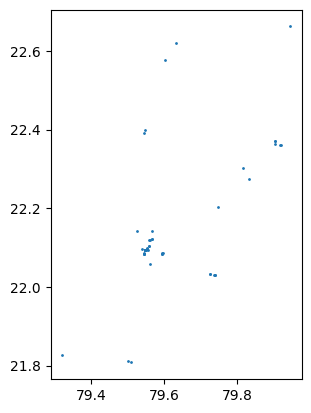

In [10]:
gdf.plot(markersize=1)

In [11]:
save_shapefiles(gdf, OUTPUT_DATA_DIR, "gov_buildings_new", formats=["parquet", "kml"])

In [12]:
gdf.head()

,S.No.,District,DISCOM,Name of Institutions/ Consumer,Govt. Dept. Name,IVRS/ Consumer Code,lat,lon,Average Monthly Electricity Consumption (kWh),Annual Consumption (kWh),...,Ownership a of Premises (Govt./ Private),Solar Rooftop Capacity (in kW) as per Contract Demand (C-1),Solar Rooftop Capacity (in kW) as per shadow free useful area of Consumer's Premise (C-2),Solar Rooftop Capacity (in kW) as per Monthly Consumption (C-3),Solar Rooftop Capacity (in kW) as per DTR Capacity (C-4),Rated Capacity of DTR (kVA),Solar Rooftop Capacity Installed/ Proposed to Install at concerned DTR (in kW),"Critical obseravation/ remarks, if any",Unnamed: 30,geometry
0,1.0,Seoni,MPPoKVVCL,"AE HOUSING BOARD JBP, CHHIDIYA PALARI, TRIBAL ...",Tribal Research and Development Institute (TRDI),1313046966,22.084803,79.594453,"7,950","95,400",...,Govt.,53.0,65.0,66.0,72.0,100,0.0,NaN,NaN,POINT (79.59445 22.08480)
1,2.0,Seoni,MPPoKVVCL,"ASSISTENT ENGINEER TESTING, 132 KV SUB STATION...",Transmission company,1412006481,22.102893,79.557736,"11,123","133,473",...,Govt.,65.0,79.0,93.0,144.0,200,0.0,NaN,NaN,POINT (79.55774 22.10289)
2,3.0,Seoni,MPPoKVVCL,"A E MPPKVV CO LTD, 132 KV SUBSTATION, SC 89279...",Transmission company,1121014415,22.620690,79.631206,"4,487","53,849",...,Govt.,50.0,61.0,37.0,18.0,25,0.0,NaN,NaN,POINT (79.63121 22.62069)
3,4.0,Seoni,MPPoKVVCL,"A.E. 220 KV SUB STATION, SIMARIYA, MPPKVV CO.L...",Transmission company,1313018680,22.141547,79.525387,"12,836","154,032",...,Govt.,50.0,61.0,107.0,18.0,25,0.0,NaN,NaN,POINT (79.52539 22.14155)
4,5.0,Seoni,MPPoKVVCL,"PRINCIPAL I T I, S C NO. 10701, INDUSTRIAL TEC...",Technical Education and Skill Development,1313039188,22.086900,79.595713,"1,196","14,357",...,Govt.,74.0,90.0,10.0,144.0,200,0.0,NaN,NaN,POINT (79.59571 22.08690)


## Clustering

/Users/amiremami/miniconda3/envs/clustering/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


<Axes: >

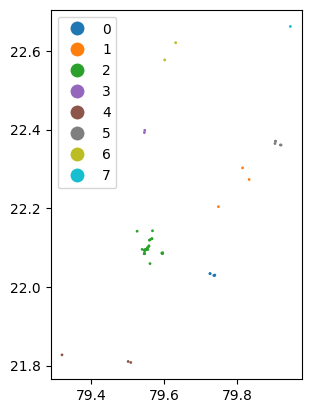

In [13]:
# cluster with kmeans
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=8, random_state=0)
gdf["cluster"] = [str(i) for i in kmeans.fit_predict(gdf[["lon", "lat"]])]
gdf.plot(column="cluster", markersize=1, legend=True)

In [14]:
# from sklearn.cluster import HDBSCAN

# dbscan = HDBSCAN(n_jobs=-1)
# gdf["cluster"] = dbscan.fit_predict(gdf[["lon", "lat"]])
# gdf.plot(column="cluster", markersize=1, legend=True)

<Axes: >

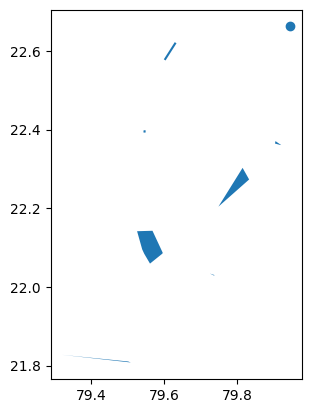

In [15]:
gdf.dissolve("cluster").convex_hull.plot()

## Travelling Salesman

In [16]:
gdf_projected = gdf.to_crs("EPSG:24378")

In [17]:
gdf_projected.lat = gdf_projected.geometry.y
gdf_projected.lon = gdf_projected.geometry.x

In [18]:
from scipy.spatial import distance_matrix

# Calculate the distance matrix
dist_matrix = distance_matrix(gdf_projected[["lon", "lat"]], gdf_projected[["lon", "lat"]])

In [19]:
from ortools.constraint_solver import pywrapcp
from ortools.constraint_solver import routing_enums_pb2

In [20]:
# make list of latlon tuples
lonlat = [(lon, lat) for lon, lat in zip(gdf_projected.lon, gdf_projected.lat)]

In [21]:
from scipy.spatial import distance_matrix
from ortools.constraint_solver import pywrapcp
from ortools.constraint_solver import routing_enums_pb2

# Coordinates example
coordinates = lonlat

# Distance matrix
dist_matrix = distance_matrix(coordinates, coordinates)

def create_data_model():
    return {'distance_matrix': dist_matrix, 'num_locations': len(coordinates)}

data = create_data_model()
manager = pywrapcp.RoutingIndexManager(data['num_locations'], 1, 0)
routing = pywrapcp.RoutingModel(manager)

def distance_callback(from_index, to_index):
    from_node = manager.IndexToNode(from_index)
    to_node = manager.IndexToNode(to_index)
    return int(data['distance_matrix'][from_node][to_node])

transit_callback_index = routing.RegisterTransitCallback(distance_callback)
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC)
search_parameters.local_search_metaheuristic = (
    routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH)
search_parameters.time_limit.seconds = 30

solution = routing.SolveWithParameters(search_parameters)

In [22]:
# Print the solution (ordered route)
if solution:
    index = routing.Start(0)
    route = []
    while not routing.IsEnd(index):
        route.append(manager.IndexToNode(index))
        index = solution.Value(routing.NextVar(index))
    route.append(manager.IndexToNode(index))
    print("Optimal Path:", route)

Optimal Path: [0, 14, 4, 6, 26, 27, 43, 36, 41, 35, 34, 33, 32, 31, 30, 23, 17, 37, 46, 45, 24, 38, 1, 9, 8, 25, 16, 7, 44, 3, 15, 39, 5, 2, 10, 50, 11, 19, 21, 51, 22, 12, 48, 28, 29, 20, 40, 42, 49, 18, 47, 13, 0]


In [23]:
# make a multi-line string
from shapely.geometry import LineString

In [24]:
line_gdf = gpd.GeoDataFrame(
    data={"start_index": route[:-1], "end_index": route[1:]},
    geometry=[
        LineString(
            [
                gdf_projected.iloc[route[i]].geometry,
                gdf_projected.iloc[route[i + 1]].geometry,
            ]
        )
        for i in range(len(route) - 1)
    ],
)

In [25]:
line_gdf

,start_index,end_index,geometry
0,0,14,"LINESTRING (3955100.072 -178508.009, 3955160.6..."
1,14,4,"LINESTRING (3955160.633 -178505.637, 3955205.6..."
2,4,6,"LINESTRING (3955205.662 -178259.481, 3954959.6..."
3,6,26,"LINESTRING (3954959.645 -178376.239, 3950025.3..."
4,26,27,"LINESTRING (3950025.310 -179088.087, 3950025.3..."
5,27,43,"LINESTRING (3950025.310 -179088.087, 3949947.5..."
6,43,36,"LINESTRING (3949947.596 -179119.325, 3949989.6..."
7,36,41,"LINESTRING (3949989.679 -179051.432, 3949237.6..."
8,41,35,"LINESTRING (3949237.606 -177944.648, 3949976.5..."
9,35,34,"LINESTRING (3949976.519 -178108.910, 3949976.5..."


In [ ]:
# add start and end cluster names
line_gdf["start_cluster"] = gdf_projected.iloc[line_gdf.start_index].cluster.values
line_gdf["end_cluster"] = gdf_projected.iloc[line_gdf.end_index].cluster.values

In [ ]:
filtered_line_gdf = line_gdf[line_gdf["start_cluster"] == line_gdf["end_cluster"]]

In [ ]:
filtered_line_gdf.length.sum()

In [ ]:
fig, ax = plt.subplots(figsize=(15,15))
gdf_projected.plot(ax=ax, column="cluster", markersize=35)
# line_gdf.plot(ax=ax)
filtered_line_gdf.plot(ax=ax, color="black")

# add a 1km line to show scale on the plot
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
length = 10000
length_name = "10km"
ax.plot([xmax - length, xmax], [ymin, ymin], color="white", linewidth=5, linestyle="-")
ax.plot([xmax - length, xmax], [ymin, ymin], color="black", linewidth=2, linestyle="-")
ax.text(xmax - length/2, ymin + 400, length_name, fontsize=6, ha="center")

# axes off
ax.axis("off")

In [ ]:
flight_paths_gdf = filtered_line_gdf.dissolve("start_cluster").reset_index()[["start_cluster", "geometry"]]
flight_paths_gdf.rename(columns={"start_cluster": "cluster"}, inplace=True)
flight_paths_gdf.set_crs("EPSG:24378", inplace=True)

In [ ]:
# get count of buildings in each cluster
n_buildings_per_cluster = gdf_projected.groupby("cluster").size()
flight_paths_gdf["Number of Buildings"] = flight_paths_gdf["cluster"].map(n_buildings_per_cluster)

In [ ]:
flight_paths_gdf["Length (km)"] = round(flight_paths_gdf.length / 1000, 2)

In [ ]:
line_gdf[line_gdf["start_cluster"] != line_gdf["end_cluster"]].length

In [ ]:
save_shapefiles(
    flight_paths_gdf.to_crs("EPSG:4326"),
    OUTPUT_DATA_DIR,
    "flight_paths_grouped",
    formats=["parquet", "kml"],
)

In [ ]:
save_shapefiles(
    gdf.to_crs("EPSG:4326"),
    OUTPUT_DATA_DIR,
    "gov_buildings_grouped",
    formats=["parquet", "kml"],
)

In [ ]:
flight_path_buffered_gdf = flight_paths_gdf.copy()
flight_path_buffered_gdf["geometry"] = flight_path_buffered_gdf.buffer(50)

save_shapefiles(
    flight_path_buffered_gdf.to_crs("EPSG:4326"),
    OUTPUT_DATA_DIR,
    "flight_paths_grouped_buffered",
    formats=["parquet", "kml"],
)